In [2]:
import pathlib
import geopandas as gpd
import pandas as pd
import numpy as np

In [3]:
DATA_DIRECTORY = pathlib.Path().resolve() / "Data_Project"

### Using the read_file function to read a geopackage, Geopackage of the RegSO data for 2025, can be downloaded as a .gpkg file from the link: https://www.scb.se/vara-tjanster/oppna-data/oppna-geodata/regso/

In [4]:
regso_data = gpd.read_file(DATA_DIRECTORY / "RegSO_2025.gpkg")

<Axes: >

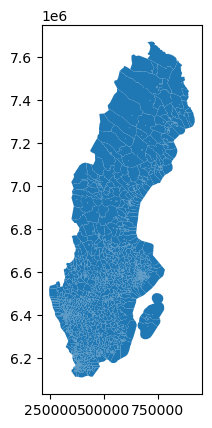

In [5]:
regso_data.plot()

In [6]:
regso_data.head()

,objectid,objektidentitet,regsokod,regsonamn,lanskod,kommunkod,kommunnamn,version,geometry
0,1,5e2188d5-3574-41ce-9a96-105b14813894,0821R002,Högsby,08,0821,Högsby,2025_v1,"POLYGON ((562382.748 6338512.394, 562420.703 6..."
1,2,638ad5dd-632f-4faf-8997-63e5dc01af27,0821R003,Högsby omland,08,0821,Högsby,2025_v1,"POLYGON ((563120.017 6347300.265, 563128.156 6..."
2,3,ad6028f7-3047-415d-b3ff-6ba4b1fe1149,0821R004,Långemåla,08,0821,Högsby,2025_v1,"POLYGON ((569475.955 6338269.854, 569637.928 6..."
3,4,9655a6cd-af6b-4936-8bea-67a3aa36b243,0834R001,Bergkvara,08,0834,Torsås,2025_v1,"POLYGON ((565795.01 6253520.434, 565833.155 62..."
4,5,8a0e5d2c-e3a7-45c8-996e-e0e4f7bb8bef,0834R002,Gullabo,08,0834,Torsås,2025_v1,"POLYGON ((546507.823 6265346.757, 547989.899 6..."


### Here, we will try to extract data from a WFS Format. The link for RegSO data is available at: https://www.scb.se/vara-tjanster/oppna-data/oppna-geodata/regso/ Using the WFS link, https://geodata.scb.se/geoserver/stat/wfs?service=wfs&version=1.1.0&request=GetCapabilities, we can extract any dataset from the WFS server of SCB We will use the urban area dataset (Tätorter to calculate the urban area for the city.

<Axes: >

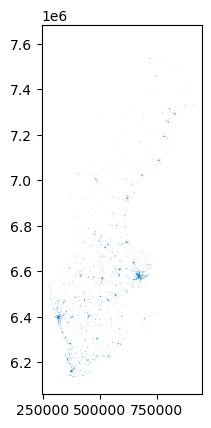

In [8]:
urban_area = gpd.read_file(
    "https://geodata.scb.se/geoserver/stat/wfs"
    "?service=WFS"
    "&version=1.1.0"
    "&request=GetFeature"
    "&typeName=stat:Tatorter_2023"
    "&outputFormat=application/json"
)
urban_area.plot()

### Urban area, extracted from the WFS data server is then written as a geopackage file

In [14]:
urban_area.to_file(
    DATA_DIRECTORY / "urban_area.gpkg",
    layer="tatorter_2023",
    driver="GPKG"
)

### Once the datasets are imported into the working code, it is important to check their *coordinate reference system (CRS)* to be able to make sure that we can conduct different spatial features between the two geodataframes. In case the CRS for one of the files is different, it can be changed as follows: regso_data = regso_data.to_crs("EPSG:3006").

In [15]:
regso_data.crs

<Projected CRS: EPSG:3006>
Name: SWEREF99 TM
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Sweden - onshore and offshore.
- bounds: (10.03, 54.96, 24.17, 69.07)
Coordinate Operation:
- name: SWEREF99 TM
- method: Transverse Mercator
Datum: SWEREF99
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [16]:
urban_area.crs

<Projected CRS: EPSG:3006>
Name: SWEREF99 TM
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Sweden - onshore and offshore.
- bounds: (10.03, 54.96, 24.17, 69.07)
Coordinate Operation:
- name: SWEREF99 TM
- method: Transverse Mercator
Datum: SWEREF99
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [17]:
urban_area.head()

,objectid,uuid,tatortskod,tatort,kommun,kommunnamn,lan,lannamn,area_ha,bef,ar,validfrom,validto,geometry
0,1,7980ea86-c122-470c-812a-5d9283102c3e,0114TB103,Löwenströmska lasarettet,0114,Upplands Väsby,01,Stockholm,67,605,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((665241.653 6604064.79, 665249...."
1,2,9c084daf-3ed7-45a1-b4fd-8410cd8690b0,0114TB107,Båtbyggartorp och Harva,0114,Upplands Väsby,01,Stockholm,50,285,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((661170.589 6601175.268, 661169..."
2,3,9121f066-5ba6-4a98-a512-52888fe82ed5,0115TB101,Brottby,0115,Vallentuna,01,Stockholm,39,213,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((683178.071 6607044.212, 683179..."
3,4,eb808fa9-cdb9-4d60-abb7-7e8897e99ed6,0115TB102,"Ekskogen, Älgeby och Långsjötorp",0115,Vallentuna,01,Stockholm,257,400,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((689090.546 6610955.103, 689088..."
4,5,07587482-4a89-4573-a758-44c719f1273f,0115TB103,Ekskogen,0115,Vallentuna,01,Stockholm,70,278,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((682344.035 6616412.305, 682341..."


### Once we have the RegSO dataset (regso_data), and urban area dataset (urban_area), we can create another set of datasets associated with a specific Kommunekod
### In this example, I have chosen **Göteborg** as the kommun, with Kommunkod: **"1480"**.

<Axes: >

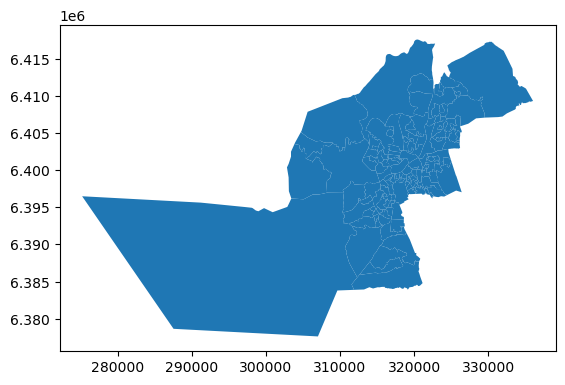

In [17]:
regso_got = regso_data[regso_data["kommunkod"] == "1480"]
regso_got.plot()

In [18]:
regso_got.to_file(DATA_DIRECTORY / "regso_got.gpkg")

<Axes: >

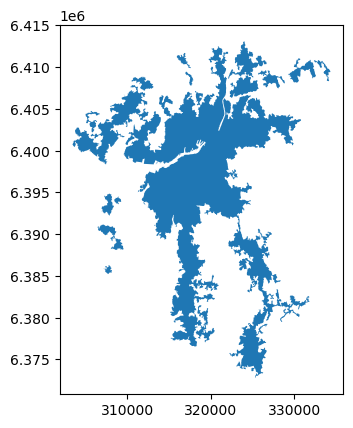

In [19]:
urban_got = urban_area[urban_area["kommun"] == "1480"]
urban_got.plot()

In [20]:
urban_got.to_file(DATA_DIRECTORY / "urban_got.gpkg")

### Once we have the Regso and Urban area data at the kommun level, we use the Overlay analysis method to get Urban area by regso, using the overlay operation **intersection**. This gives us the Urban Area by RegSO.

,objectid_1,objektidentitet,regsokod,regsonamn,lanskod,kommunkod,kommunnamn_1,version,id,objectid_2,...,kommun,kommunnamn_2,lan,lannamn,area_ha,bef,ar,validfrom,validto,geometry
0,545,c17634a8-9640-4634-bede-42938615d145,1480R050,Hjällbo östra,14,1480,Göteborg,2025_v1,Tatorter_2023.1482,1482,...,1480,Göteborg,14,Västra Götaland,1170,48217,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((323511.152 6407582.775, 323525..."
1,546,42e4e507-badf-4a3f-b6d0-ebb03ffd70e4,1480R051,Hovås,14,1480,Göteborg,2025_v1,Tatorter_2023.1491,1491,...,1480,Göteborg,14,Västra Götaland,27155,674529,2023,2023-12-31,2025-12-31,"MULTIPOLYGON (((318539.848 6387731.646, 318575..."
2,2164,d6968188-6480-4ebe-b5fc-20cd13fbe971,1480R116,Rambergsstaden östra,14,1480,Göteborg,2025_v1,Tatorter_2023.1491,1491,...,1480,Göteborg,14,Västra Götaland,27155,674529,2023,2023-12-31,2025-12-31,"POLYGON ((318378.518 6401516.61, 318386.162 64..."
3,891,46da28df-5dfc-435c-8641-1ebde98ddb7c,1480R055,Högsbotorp västra,14,1480,Göteborg,2025_v1,Tatorter_2023.1491,1491,...,1480,Göteborg,14,Västra Götaland,27155,674529,2023,2023-12-31,2025-12-31,"POLYGON ((316965.881 6396610.339, 316992.028 6..."
4,2151,5960459f-c432-4c27-b909-0c804aebfabb,1480R099,Majorna Gråberget,14,1480,Göteborg,2025_v1,Tatorter_2023.1491,1491,...,1480,Göteborg,14,Västra Götaland,27155,674529,2023,2023-12-31,2025-12-31,"POLYGON ((316559.212 6398722.879, 316573.296 6..."


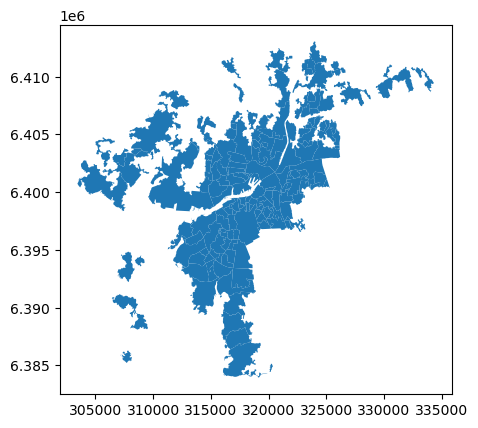

In [21]:
urban_got_by_regso = regso_got.overlay(urban_got, how="intersection")
urban_got_by_regso.plot()
urban_got_by_regso.head()

### Clean up the data to include only key attributes. **geometry** and the **regsokod** are the two most important attributes.

In [23]:
urban_got_by_regso = urban_got_by_regso[["regsokod", "regsonamn", "kommunkod", "geometry"]]
urban_got_by_regso.head()

,regsokod,regsonamn,kommunkod,geometry
0,1480R050,Hjällbo östra,1480,"MULTIPOLYGON (((323511.152 6407582.775, 323525..."
1,1480R051,Hovås,1480,"MULTIPOLYGON (((318539.848 6387731.646, 318575..."
2,1480R116,Rambergsstaden östra,1480,"POLYGON ((318378.518 6401516.61, 318386.162 64..."
3,1480R055,Högsbotorp västra,1480,"POLYGON ((316965.881 6396610.339, 316992.028 6..."
4,1480R099,Majorna Gråberget,1480,"POLYGON ((316559.212 6398722.879, 316573.296 6..."


### Before moving to the next step of spatial data analysis, lets visualize how the RegSO data, and Urban Area by RegSO look like.
### We use the approach to plot multiple layers on a single plot now.
### For better orientation, it is often helpful to add a base map to a map plot. A base map,from map provider **OpenStreetMap** is used here.
### It can be done by importing the Python Package **contextily**.

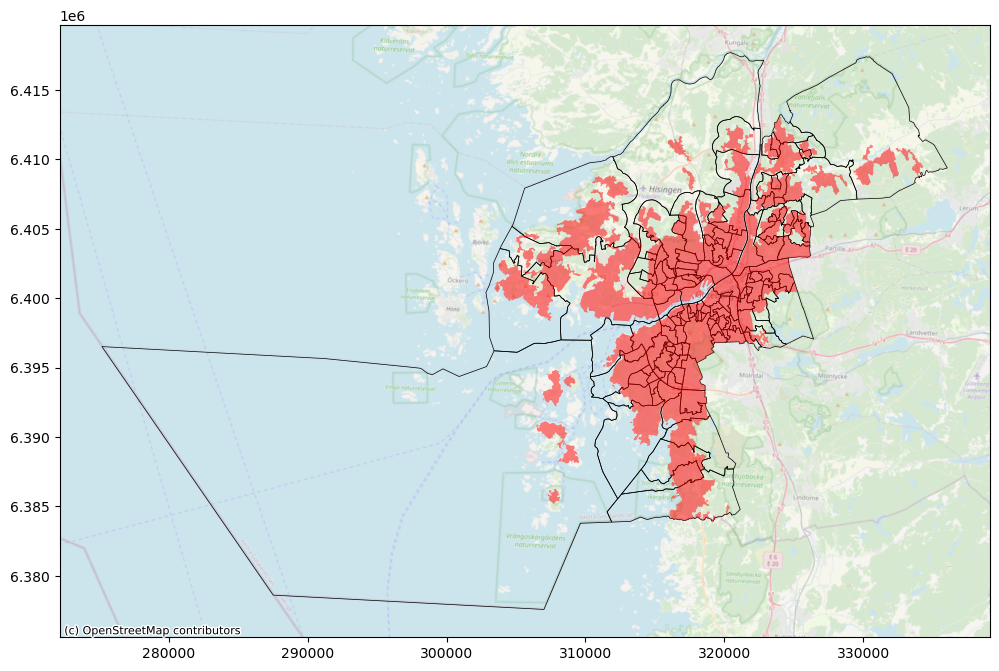

In [25]:
#Plotting multiple map layers
import contextily as cx
axes = regso_got.plot(
    figsize=(12, 8),
    edgecolor ="black", linewidth = 0.5,
    facecolor="none",
  )
urban_got_by_regso.plot(ax=axes, facecolor="red", alpha = 0.5)

# add basemap to EACH axis
cx.add_basemap(axes, source=cx.providers.OpenStreetMap.Mapnik, 
               attribution=("(c) OpenStreetMap contributors"), #Important to provide attribution, but in this case it automatically appears, so it is not necessary
               crs=regso_got.crs, alpha=0.6, zoom=11)

### Now, since our objective for this analysis is to calculate the urbanized area for each of the Regso. We will first calculate the area for each geometry of urban area in GOT. 

In [27]:
urban_got_by_regso["urban_area"] = urban_got_by_regso.geometry.area
print(urban_got_by_regso)

     regsokod             regsonamn kommunkod  \
0    1480R050         Hjällbo östra      1480   
1    1480R051                 Hovås      1480   
2    1480R116  Rambergsstaden östra      1480   
3    1480R055     Högsbotorp västra      1480   
4    1480R099     Majorna Gråberget      1480   
..        ...                   ...       ...   
154  1480R142            Tuve östra      1480   
155  1480R143                  Utby      1480   
156  1480R145                 Ängås      1480   
157  1480R146               Önnered      1480   
158  1480R147                Överås      1480   

                                              geometry    urban_area  
0    MULTIPOLYGON (((323511.152 6407582.775, 323525...  6.051451e+05  
1    MULTIPOLYGON (((318539.848 6387731.646, 318575...  2.865952e+06  
2    POLYGON ((318378.518 6401516.61, 318386.162 64...  1.434672e+05  
3    POLYGON ((316965.881 6396610.339, 316992.028 6...  4.470445e+05  
4    POLYGON ((316559.212 6398722.879, 316573.296 6...  

### As we can see in the plot, multiple geometries can be seen in some of the RegSos. While we have **147** RegSOs, this dataset has **159** areas.
### We will group the dataset based on **regsokod**. 

In [29]:
urban_area_sqkm = urban_got_by_regso.groupby("regsokod").urban_area.sum()/1e6
print(urban_area_sqkm)

regsokod
1480R001    3.164268
1480R002    5.064055
1480R003    2.658972
1480R004    3.226387
1480R005    1.193531
              ...   
1480R143    2.276059
1480R144    0.469532
1480R145    1.520596
1480R146    2.501146
1480R147    0.827124
Name: urban_area, Length: 147, dtype: float64


### At this point, urban_area_sqkm is not yet a DataFrame — it’s a Series. We will merge it with the **regso_got** DataFrame, based on the regsokod. So, now the **regso_got** includes urban area as well.

In [30]:
#Using spatial join, this area can be added to regso_got_data
regso_got =  regso_got.merge(urban_area_sqkm, on="regsokod", how="left")
regso_got.head()

,objectid,objektidentitet,regsokod,regsonamn,lanskod,kommunkod,kommunnamn,version,geometry,urban_area
0,545,c17634a8-9640-4634-bede-42938615d145,1480R050,Hjällbo östra,14,1480,Göteborg,2025_v1,"POLYGON ((323472.297 6407681.235, 323511.152 6...",0.605145
1,546,42e4e507-badf-4a3f-b6d0-ebb03ffd70e4,1480R051,Hovås,14,1480,Göteborg,2025_v1,"POLYGON ((318974.816 6391538.521, 319414.27 63...",2.865952
2,2164,d6968188-6480-4ebe-b5fc-20cd13fbe971,1480R116,Rambergsstaden östra,14,1480,Göteborg,2025_v1,"POLYGON ((318376.094 6401516.69, 318378.518 64...",0.143467
3,891,46da28df-5dfc-435c-8641-1ebde98ddb7c,1480R055,Högsbotorp västra,14,1480,Göteborg,2025_v1,"POLYGON ((316899.568 6396772.106, 316965.881 6...",0.447044
4,2151,5960459f-c432-4c27-b909-0c804aebfabb,1480R099,Majorna Gråberget,14,1480,Göteborg,2025_v1,"POLYGON ((316544.428 6398740.815, 316559.212 6...",0.363313


In [42]:
#Clean up to remove unnecessary columns
regso_got = regso_got[["objectid", "regsokod", "regsonamn", "kommunkod", "kommunnamn", "urban_area", "geometry"]]
regso_got.head()
regso_got.to_file(DATA_DIRECTORY / "regso_got.gpkg")

### Now, we have an urban area for each RegSO in Göteborg,we will import dataset on Population by RegSO and calculate the population density for each RegSO.
### Population data is available at: https://www.scb.se/hitta-statistik/regional-statistik-och-kartor/regionala-indelningar/regionala-statistikomraden-regso/regso-tabellerna-i-statistikdatabasen---information-och-instruktioner/

In [43]:
#Importing dataset on Population
population_by_regso = gpd.read_file(DATA_DIRECTORY / "Population_by_Region.xlsx")
population_by_regso.head()

,regsokod,Population_2023
0,1480R001,5843
1,1480R002,5798
2,1480R003,6675
3,1480R004,6058
4,1480R005,3728


### We will again conduct a merge to add population dataset to the regso geodataframe. And, after adding the population data, we will conduct a simple mathematical operation to calculate Population density and add it as a column in the regso_got geodataframe.

In [44]:
regso_got =  regso_got.merge(population_by_regso, on="regsokod", how="left")
regso_got.head()

,objectid,regsokod,regsonamn,kommunkod,kommunnamn,urban_area,geometry,Population_2023
0,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,"POLYGON ((323472.297 6407681.235, 323511.152 6...",1963
1,546,1480R051,Hovås,1480,Göteborg,2.865952,"POLYGON ((318974.816 6391538.521, 319414.27 63...",3608
2,2164,1480R116,Rambergsstaden östra,1480,Göteborg,0.143467,"POLYGON ((318376.094 6401516.69, 318378.518 64...",2837
3,891,1480R055,Högsbotorp västra,1480,Göteborg,0.447044,"POLYGON ((316899.568 6396772.106, 316965.881 6...",4490
4,2151,1480R099,Majorna Gråberget,1480,Göteborg,0.363313,"POLYGON ((316544.428 6398740.815, 316559.212 6...",4344


In [45]:
regso_got["Pop_Density"] = regso_got["Population_2023"] / regso_got["urban_area"]
regso_got.head()

,objectid,regsokod,regsonamn,kommunkod,kommunnamn,urban_area,geometry,Population_2023,Pop_Density
0,545,1480R050,Hjällbo östra,1480,Göteborg,0.605145,"POLYGON ((323472.297 6407681.235, 323511.152 6...",1963,3243.850327
1,546,1480R051,Hovås,1480,Göteborg,2.865952,"POLYGON ((318974.816 6391538.521, 319414.27 63...",3608,1258.918454
2,2164,1480R116,Rambergsstaden östra,1480,Göteborg,0.143467,"POLYGON ((318376.094 6401516.69, 318378.518 64...",2837,19774.554674
3,891,1480R055,Högsbotorp västra,1480,Göteborg,0.447044,"POLYGON ((316899.568 6396772.106, 316965.881 6...",4490,10043.743878
4,2151,1480R099,Majorna Gråberget,1480,Göteborg,0.363313,"POLYGON ((316544.428 6398740.815, 316559.212 6...",4344,11956.631289


### We write the final dataframe, and then we have regso_got.gpkg with additional data on urban area, population, and population density. At each stage of writing, a different geodataframe can be made however, I have overwritten the same file.

In [46]:
regso_got.to_file(DATA_DIRECTORY / "regso_got.gpkg")

Now, we have geodataframe **regso_got.gpkg**, with geometry of the 147 RegSO of Göteborg, along with **Urban_area**, **Population**, and **Population density**.

## It is important to note that, while **regso_got.gpkg** has all the datasets, but they only have the geometry of the RegSO based on regsokod. In order to access the geometry for urban areas, we can access **urban_got.gpkg**.